In [1]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam, Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

import time

c:\Users\kgl07\anaconda3\envs\course42186\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set random seed for reproducibility
pyro.set_rng_seed(42)

In [3]:
# load the data
test_data_path = "small_test_data.csv"
test_label_path = "small_test_labels.csv"
test_data = pd.read_csv(test_data_path).values.astype(np.float32)
test_label = pd.read_csv(test_label_path).values

val_data_path = "small_val_data.csv"
val_label_path = "small_val_labels.csv"
val_data = pd.read_csv(val_data_path).values.astype(np.float32)
val_label = pd.read_csv(val_label_path).values

# Presentation of data

In [4]:
def normalize_data(data):
    # Z-score normalization per gene
    X_train_mean = data.mean(axis=0)
    X_train_std = data.std(axis=0) + 1e-6  # avoid div-by-zero
    X_norm = (data - X_train_mean) / X_train_std
    X_clipped = np.clip(X_norm, -15, 15)
    return X_clipped, X_train_mean, X_train_std


X_norm, X_train_mean, X_train_std = normalize_data(test_data)

Data shape: (200, 400)
Label shape: (200, 1)
AML 118 ALL 68 Normal 14


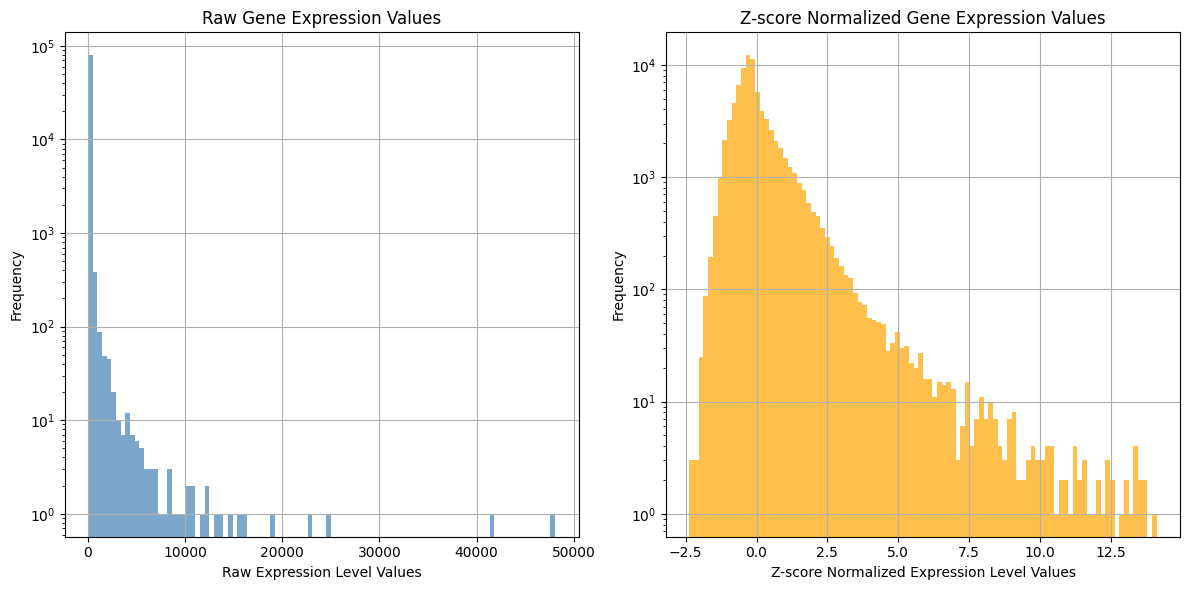

In [5]:
def present_data(data, label, norm_data):
    print("Data shape:", data.shape)
    print("Label shape:", label.shape)
    print(f"AML", np.sum(label == 0), "ALL", np.sum(label == 1), "Normal", np.sum(label == 2))

    # Flatten the matrix (5000 subjects × 60,000 genes) into a 1D array
    raw_flat_gene_expr = data.flatten()
    norm_flat_gene_expr = norm_data.flatten()

    # Plot distributions in two subplots
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(raw_flat_gene_expr, bins=100, color='steelblue', alpha=0.7)
    plt.title("Raw Gene Expression Values")
    plt.xlabel("Raw Expression Level Values")
    plt.ylabel("Frequency")
    plt.grid()
    plt.yscale('log')  # Optional: log scale helps if values span wide range
    plt.subplot(1, 2, 2)
    plt.hist(norm_flat_gene_expr, bins=100, color='orange', alpha=0.7)
    plt.title("Z-score Normalized Gene Expression Values")
    plt.xlabel("Z-score Normalized Expression Level Values")
    plt.ylabel("Frequency")
    plt.grid()
    plt.yscale('log')  # Optional: log scale helps if values span wide range
    plt.tight_layout()
    plt.show()



present_data(val_data, val_label, X_norm)


# Supervised PPCA model

In [6]:
def supervised_ppca_model(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape

    # Sample W from prior
    W = pyro.sample("W", dist.Normal(0., 1.).expand([latent_dim, n_genes]).to_event(2))

    # Sigma is now a per-gene parameter
    sigma = pyro.param("sigma_loc", torch.ones(n_genes), constraint=dist.constraints.positive)

    # Classifier weights (point estimate)
    A = pyro.param("A", torch.randn(n_classes, latent_dim))
    b = pyro.param("b", torch.zeros(n_classes))

    with pyro.plate("data", n_samples):
        # Sample latent variable
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))

        # Likelihood for gene expression
        x_loc = torch.matmul(z, W)
        pyro.sample("obs", dist.Normal(x_loc, sigma).to_event(1), obs=X)

        # Likelihood for class label
        probs = torch.softmax(torch.matmul(z, A.T) + b, dim=-1)  # Fixed from sigmoid to softmax
        pyro.sample("y", dist.Categorical(probs=probs), obs=y)


def supervised_ppca_guide(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape

    # Variational posterior for W
    w_loc = pyro.param("w_loc", torch.randn(latent_dim, n_genes))
    w_scale = pyro.param("w_scale", torch.ones(latent_dim, n_genes), constraint=dist.constraints.positive)
    pyro.sample("W", dist.Normal(w_loc, w_scale).to_event(2))

    # Variational posterior for z
    z_loc = pyro.param("z_loc", torch.randn(n_samples, latent_dim))
    z_scale = pyro.param("z_scale", torch.ones(n_samples, latent_dim), constraint=dist.constraints.positive)
    
    with pyro.plate("data", n_samples):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))
        

### Train model

In [7]:
def SVI_PPCA(X_train, y_train, latent_dim, n_classes, n_steps):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long).flatten()

    pyro.clear_param_store()
    optimizer = Adam({"lr": 0.01})
    svi = SVI(supervised_ppca_model, supervised_ppca_guide, optimizer, loss=Trace_ELBO())

    start_time = time.time()

    for step in range(n_steps):
        loss = svi.step(X_train_tensor, y_train_tensor, latent_dim, n_classes)
        if step % (n_steps // 10) == 0:
            print(f"[Step {step}] Loss: {loss:.2f}")

    # Total time spent
    print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")


latent_dim = 100
n_classes = 3

SVI_PPCA(X_norm, test_label, latent_dim, n_classes, n_steps=3000)

[Step 0] Loss: 16515874.58
[Step 300] Loss: 479056.83
[Step 600] Loss: 287168.48
[Step 900] Loss: 243105.71
[Step 1200] Loss: 227312.41
[Step 1500] Loss: 217671.06
[Step 1800] Loss: 211759.01
[Step 2100] Loss: 206605.11
[Step 2400] Loss: 202393.80
[Step 2700] Loss: 197730.40
Total time spent: 53.51 seconds (0.89 minutes)


In [8]:
print(list(pyro.get_param_store().keys()))

['w_loc', 'w_scale', 'z_loc', 'z_scale', 'sigma_loc', 'A', 'b']


# Exploring Latent space

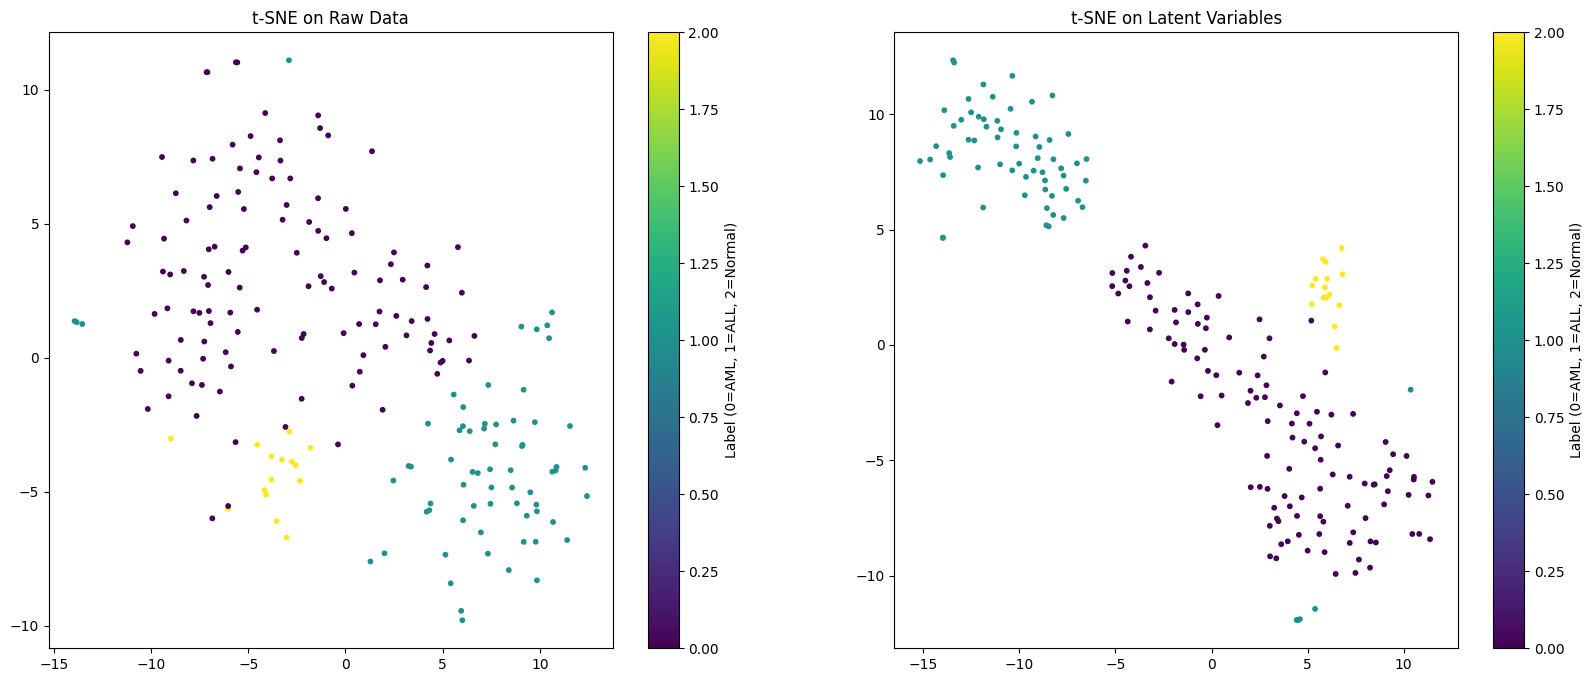

In [9]:
def TSNE_plots(z_loc, labels):
    raw_data_tsne = TSNE(n_components=2).fit_transform(X_norm)
    z_post_tsne = TSNE(n_components=2).fit_transform(z_loc.detach().cpu().numpy())

    # subplot 1: t-SNE on raw data
    plt.figure(figsize=(20, 8))
    plt.subplot(1, 2, 1)
    plt.scatter(raw_data_tsne[:, 0], raw_data_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Raw Data")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.subplot(1, 2, 2)
    plt.scatter(z_post_tsne[:, 0], z_post_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Latent Variables")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.show()


z_loc = pyro.param("z_loc").detach()

TSNE_plots(z_loc, test_label)

# Prediction on Validation data

### Freeze model parameters for prediction

In [10]:
W_post = pyro.param("w_loc")  # shape: [latent_dim, n_genes]
A = pyro.param("A")           # shape: [n_classes, latent_dim]
b = pyro.param("b")           # shape: [n_classes]

### Model for inference on z (latent space)

In [11]:
def infer_z_val_model(X_val_tensor, latent_dim):
    n_val = X_val_tensor.shape[0]
    W = pyro.param("w_loc")                # Use learned W
    sigma = pyro.param("sigma_loc")        # Learned per-gene sigma

    with pyro.plate("data", n_val):
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
        x_loc = torch.matmul(z, W)
        pyro.sample("obs", dist.Normal(x_loc, sigma).to_event(1), obs=X_val_tensor)
        

def infer_z_val_guide(X_val_tensor, latent_dim):
    n_val = X_val_tensor.shape[0]

    # New variational parameters for validation latent space
    z_loc_val = pyro.param("z_loc_val", torch.randn(n_val, latent_dim))
    z_scale_val = pyro.param("z_scale_val", torch.ones(n_val, latent_dim), constraint=dist.constraints.positive)

    with pyro.plate("data", n_val):
        pyro.sample("z", dist.Normal(z_loc_val, z_scale_val).to_event(1))


In [12]:
def SVI_z(X_val_tensor, latent_dim, n_steps):
    optimizer = ClippedAdam({"lr": 0.01})
    svi = SVI(infer_z_val_model, infer_z_val_guide, optimizer, loss=Trace_ELBO())

    start_time = time.time()

    for step in range(n_steps):
        loss = svi.step(X_val_tensor, latent_dim)
        if step % (n_steps // 10) == 0:
            print(f"[Step {step}] Loss: {loss:.2f}")

    # Total time spent
    print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")





# Normalize validation data using training statistics
X_val_norm = (val_data - X_train_mean) / X_train_std
X_val_clipped = np.clip(X_val_norm, -15, 15)
X_val_tensor = torch.tensor(X_val_clipped, dtype=torch.float32)


SVI_z(X_val_tensor, latent_dim, n_steps=3000)

[Step 0] Loss: 169450.68


[Step 300] Loss: 58009.44
[Step 600] Loss: 36662.92
[Step 900] Loss: 32103.25
[Step 1200] Loss: 30872.39
[Step 1500] Loss: 30162.80
[Step 1800] Loss: 29953.28
[Step 2100] Loss: 28934.07
[Step 2400] Loss: 28985.34
[Step 2700] Loss: 28683.06
Total time spent: 32.25 seconds (0.54 minutes)


Validation Accuracy: 0.5450


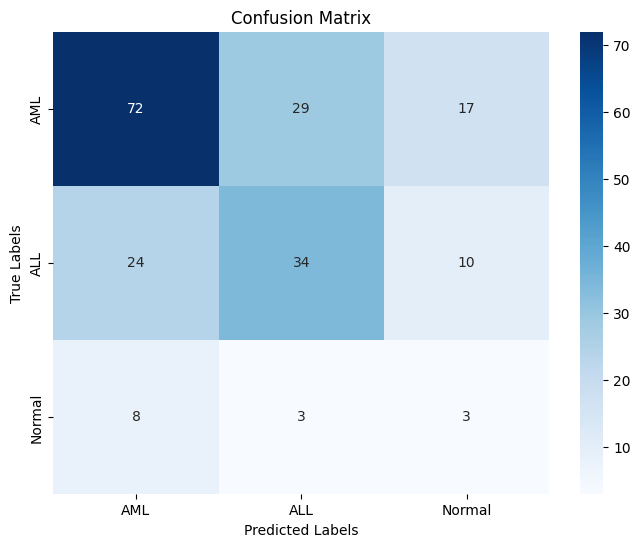

In [13]:
def predict_classes(z_loc, A, b, y_true):
    # Predict class labels using the learned latent representation
    logits = torch.matmul(z_loc, A.T) + b
    probs = torch.softmax(logits, dim=-1)
    y_hat = torch.argmax(probs, dim=-1).numpy()
    
    # Compute accuracy
    y_true = torch.tensor(y_true, dtype=torch.long).numpy()
    accuracy = (y_true.ravel() == y_hat).mean()
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Compute and plot confusion matrix
    conf_matrix = confusion_matrix(y_true, y_hat)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["AML", "ALL", "Normal"], yticklabels=["AML", "ALL", "Normal"])
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()
    return y_hat


z_loc_val = pyro.param("z_loc_val").detach()  # shape: [n_val_samples, latent_dim]

y_hat_val = predict_classes(z_loc_val, A, b, val_label)



# Evaluating importance of features (genes)

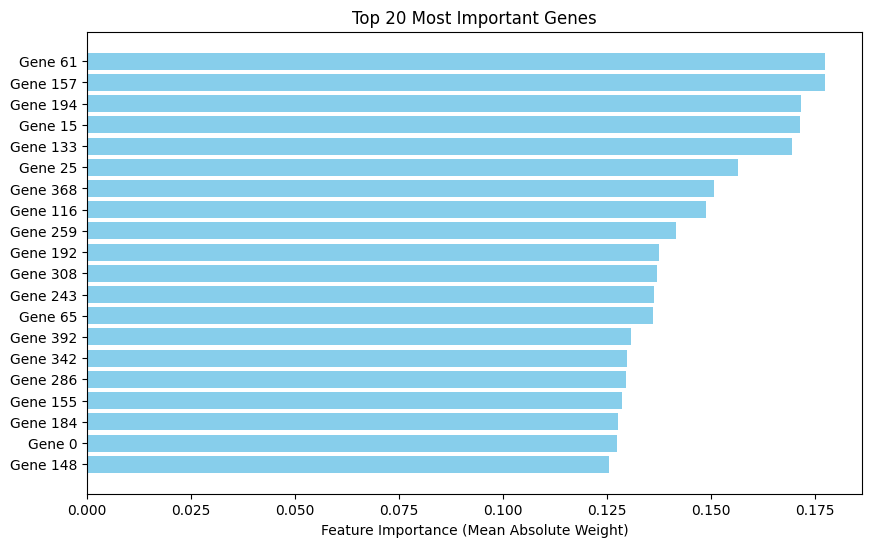

In [14]:
def compute_feature_importance(W_post, top_n=20):

    # Compute feature importance as the mean absolute weight across latent dimensions
    feature_importance = np.abs(W_post).mean(axis=0)  # Shape: [n_genes]

    # Sort genes by importance and select the top N
    top_indices = np.argsort(feature_importance)[-top_n:]  # Indices of top N genes
    top_importance = feature_importance[top_indices]

    return top_indices, top_importance


def plot_top_genes(top_indices, top_importance, top_n=20, gene_names=None):

    # Use generic names if gene names are not provided
    if gene_names is None:
        top_features = [f"Gene {i}" for i in top_indices]
    else:
        top_features = [gene_names[i] for i in top_indices]

    # Plot the top N most important genes
    plt.figure(figsize=(10, 6))
    plt.barh(top_features, top_importance, color="skyblue")
    plt.xlabel("Feature Importance (Mean Absolute Weight)")
    plt.title(f"Top {top_n} Most Important Genes")
    plt.show()


# Example usage
W_post = pyro.param("w_loc").detach().numpy()  # Shape: [latent_dim, n_genes]
top_n = 20
top_indices, top_importance = compute_feature_importance(W_post, top_n=top_n)
plot_top_genes(top_indices, top_importance, top_n=top_n)